In [1]:
import os
import random
import torch
import torch.nn as nn
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
from tqdm import tqdm
from PIL import Image

In [2]:
seed = 42
random.seed(seed)
torch.manual_seed(seed)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(seed)

if torch.backends.mps.is_available():
    device = "mps"
elif torch.cuda.is_available():
    device = "cuda"
else:
    device = "cpu"

print(f"Using device: {device}")

image_size = 128
latent_dim = 128
batch_size = 64
epochs = 20

lr = 0.0002
beta1 = 0.5
beta2 = 0.999
lambda_rx = 10.0
lambda_rz = 1.0

Using device: mps


In [3]:
transform = transforms.Compose([
    transforms.Resize(image_size),
    transforms.CenterCrop(image_size),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize([0.5, 0.5, 0.5, 0.5], [0.5, 0.5, 0.5, 0.5])
])

def rgba_loader(path):
    return Image.open(path).convert("RGBA")

dataset_roots = {
    128: "../testMohamed/archive32/PokemonImagesDBNew_square/square_128",
    256: "../testMohamed/archive32/PokemonImagesDBNew_square/square_256",
}

if image_size not in dataset_roots:
    raise ValueError(f"Unsupported image_size={image_size}. Use one of: {list(dataset_roots.keys())}")

dataset = torchvision.datasets.ImageFolder(
    root=dataset_roots[image_size],
    transform=transform,
    loader=rgba_loader
)

loader = DataLoader(
    dataset,
    batch_size=batch_size,
    shuffle=True,
    num_workers=0
)

print(f"Dataset size: {len(dataset)}")

Dataset size: 1187


In [4]:
def conv_block(in_ch, out_ch, use_bn=True):
    layers = [nn.Conv2d(in_ch, out_ch, 4, 2, 1)]
    if use_bn:
        layers.append(nn.BatchNorm2d(out_ch))
    layers.append(nn.LeakyReLU(0.2, inplace=True))
    return layers

def deconv_block(in_ch, out_ch):
    return [
        nn.ConvTranspose2d(in_ch, out_ch, 4, 2, 1),
        nn.BatchNorm2d(out_ch),
        nn.ReLU(inplace=True),
    ]

In [5]:
class Encoder(nn.Module):
    def __init__(self):
        super().__init__()
        if image_size < 16 or (image_size & (image_size - 1)) != 0:
            raise ValueError("image_size must be a power of 2 and >= 16")

        layers = []
        in_ch = 4
        out_ch = 64
        current_size = image_size
        first = True

        while current_size > 4:
            layers.extend(conv_block(in_ch, out_ch, use_bn=not first))
            in_ch = out_ch
            out_ch = min(out_ch * 2, 512)
            current_size //= 2
            first = False

        self.features = nn.Sequential(*layers)
        self.to_latent = nn.Sequential(
            nn.Flatten(),
            nn.Linear(in_ch * 4 * 4, 512),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Linear(512, latent_dim),
        )

    def forward(self, x):
        h = self.features(x)
        z_hat = self.to_latent(h)
        return z_hat

In [6]:
class Generator(nn.Module):
    def __init__(self):
        super().__init__()
        if image_size < 16 or (image_size & (image_size - 1)) != 0:
            raise ValueError("image_size must be a power of 2 and >= 16")

        self.from_latent = nn.Sequential(
            nn.Linear(latent_dim, 512 * 4 * 4),
            nn.ReLU(inplace=True),
        )

        layers = []
        in_ch = 512
        current_size = 4
        out_ch = 256

        while current_size < image_size:
            block_out = max(32, out_ch)
            layers.extend(deconv_block(in_ch, block_out))
            in_ch = block_out
            out_ch //= 2
            current_size *= 2

        layers.extend([nn.Conv2d(in_ch, 4, 3, 1, 1), nn.Tanh()])
        self.net = nn.Sequential(*layers)

    def forward(self, z):
        h = self.from_latent(z)
        h = h.view(-1, 512, 4, 4)
        x_hat = self.net(h)
        return x_hat

In [7]:
class DiscriminatorX(nn.Module):
    def __init__(self):
        super().__init__()
        if image_size < 16 or (image_size & (image_size - 1)) != 0:
            raise ValueError("image_size must be a power of 2 and >= 16")

        layers = []
        in_ch = 4
        out_ch = 64
        current_size = image_size
        first = True

        while current_size > 4:
            layers.extend(conv_block(in_ch, out_ch, use_bn=not first))
            in_ch = out_ch
            out_ch = min(out_ch * 2, 512)
            current_size //= 2
            first = False

        layers.append(nn.Conv2d(in_ch, 1, 4, 1, 0))
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x).view(-1)

In [8]:
class DiscriminatorZ(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(latent_dim, 512),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Linear(512, 256),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Linear(256, 1),
        )

    def forward(self, z):
        return self.net(z).view(-1)

In [9]:
E = Encoder().to(device)
G = Generator().to(device)
Dx = DiscriminatorX().to(device)
Dz = DiscriminatorZ().to(device)

bce = nn.BCEWithLogitsLoss()
l1 = nn.L1Loss()
l2 = nn.MSELoss()

opt_GE = torch.optim.Adam(
    list(E.parameters()) + list(G.parameters()),
    lr=lr,
    betas=(beta1, beta2)
)
opt_Dx = torch.optim.Adam(Dx.parameters(), lr=lr, betas=(beta1, beta2))
opt_Dz = torch.optim.Adam(Dz.parameters(), lr=lr, betas=(beta1, beta2))

In [10]:
history = {"loss_Dx": [], "loss_Dz": [], "loss_GE": [], "rec_x": [], "rec_z": []}

for epoch in range(epochs):
    pbar = tqdm(loader, desc=f"Epoch {epoch + 1}/{epochs}")
    for real, _ in pbar:
        real = real.to(device)
        b = real.size(0)

        ones = torch.ones(b, device=device)
        zeros = torch.zeros(b, device=device)

        z = torch.randn(b, latent_dim, device=device)

        # Step 1: update Dx
        opt_Dx.zero_grad()

        x_fake = G(z).detach()
        z_enc = E(real).detach()
        x_recon = G(z_enc).detach()

        dx_real = Dx(real)
        dx_fake = Dx(x_fake)
        dx_recon = Dx(x_recon)

        loss_Dx = bce(dx_real, ones) + 0.5 * (bce(dx_fake, zeros) + bce(dx_recon, zeros))
        loss_Dx.backward()
        opt_Dx.step()

        # Step 2: update Dz
        opt_Dz.zero_grad()

        z_prior = torch.randn(b, latent_dim, device=device)
        z_enc = E(real).detach()
        z_cycle = E(G(z).detach()).detach()

        dz_real = Dz(z_prior)
        dz_enc = Dz(z_enc)
        dz_cycle = Dz(z_cycle)

        loss_Dz = bce(dz_real, ones) + 0.5 * (bce(dz_enc, zeros) + bce(dz_cycle, zeros))
        loss_Dz.backward()
        opt_Dz.step()

        # Step 3: update E and G
        opt_GE.zero_grad()

        z = torch.randn(b, latent_dim, device=device)
        z_enc = E(real)
        x_recon = G(z_enc)
        x_fake = G(z)
        z_cycle = E(x_fake)

        adv_x = bce(Dx(x_fake), ones) + bce(Dx(x_recon), ones)
        adv_z = bce(Dz(z_enc), ones) + bce(Dz(z_cycle), ones)

        rec_x = l1(x_recon, real)
        rec_z = l2(z_cycle, z)

        loss_GE = adv_x + adv_z + lambda_rx * rec_x + lambda_rz * rec_z
        loss_GE.backward()
        opt_GE.step()

        history["loss_Dx"].append(loss_Dx.item())
        history["loss_Dz"].append(loss_Dz.item())
        history["loss_GE"].append(loss_GE.item())
        history["rec_x"].append(rec_x.item())
        history["rec_z"].append(rec_z.item())

        pbar.set_postfix({
            "Dx": f"{loss_Dx.item():.3f}",
            "Dz": f"{loss_Dz.item():.3f}",
            "GE": f"{loss_GE.item():.3f}",
            "Rx": f"{rec_x.item():.3f}",
            "Rz": f"{rec_z.item():.3f}",
        })

    print(
        f"Epoch {epoch + 1}/{epochs} | "
        f"Dx: {loss_Dx.item():.4f} | Dz: {loss_Dz.item():.4f} | "
        f"GE: {loss_GE.item():.4f} | RecX: {rec_x.item():.4f} | RecZ: {rec_z.item():.4f}"
    )

Epoch 1/20: 100%|██████████| 19/19 [00:38<00:00,  2.01s/it, Dx=0.126, Dz=1.210, GE=16.724, Rx=0.804, Rz=1.199]


Epoch 1/20 | Dx: 0.1261 | Dz: 1.2101 | GE: 16.7242 | RecX: 0.8039 | RecZ: 1.1986


Epoch 2/20: 100%|██████████| 19/19 [00:36<00:00,  1.91s/it, Dx=1.439, Dz=1.133, GE=29.010, Rx=0.622, Rz=1.163]


Epoch 2/20 | Dx: 1.4390 | Dz: 1.1333 | GE: 29.0095 | RecX: 0.6217 | RecZ: 1.1627


Epoch 3/20: 100%|██████████| 19/19 [00:37<00:00,  1.98s/it, Dx=1.522, Dz=1.370, GE=14.210, Rx=0.577, Rz=1.233]


...

Epoch 18/20 | Dx: 0.9421 | Dz: 1.4011 | GE: 10.2482 | RecX: 0.3332 | RecZ: 1.3618


Epoch 19/20: 100%|██████████| 19/19 [00:38<00:00,  2.01s/it, Dx=0.995, Dz=1.314, GE=8.403, Rx=0.323, Rz=1.292] 


Epoch 19/20 | Dx: 0.9946 | Dz: 1.3136 | GE: 8.4026 | RecX: 0.3234 | RecZ: 1.2919


Epoch 20/20: 100%|██████████| 19/19 [00:37<00:00,  1.98s/it, Dx=1.967, Dz=1.247, GE=12.775, Rx=0.270, Rz=1.191]

Epoch 20/20 | Dx: 1.9673 | Dz: 1.2467 | GE: 12.7753 | RecX: 0.2696 | RecZ: 1.1909


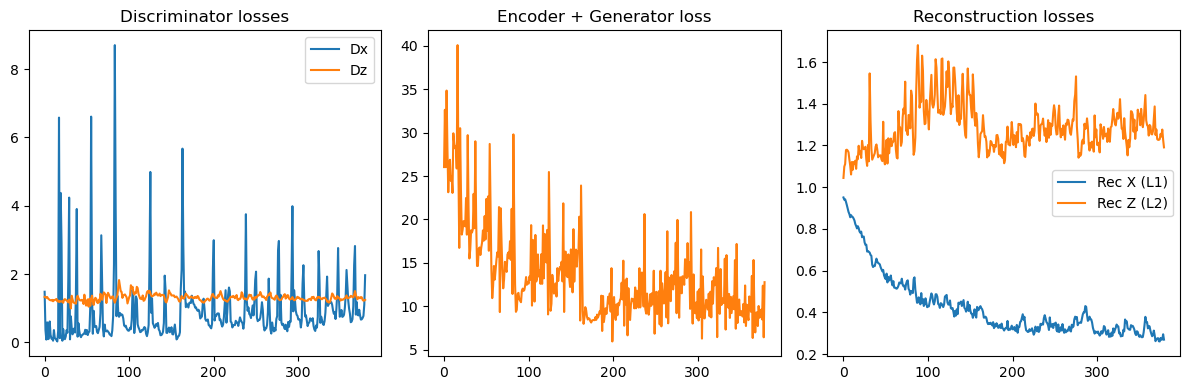

In [11]:
plt.figure(figsize=(12, 4))
plt.subplot(1, 3, 1)
plt.plot(history["loss_Dx"], label="Dx")
plt.plot(history["loss_Dz"], label="Dz")
plt.legend()
plt.title("Discriminator losses")

plt.subplot(1, 3, 2)
plt.plot(history["loss_GE"], color="tab:orange")
plt.title("Encoder + Generator loss")

plt.subplot(1, 3, 3)
plt.plot(history["rec_x"], label="Rec X (L1)")
plt.plot(history["rec_z"], label="Rec Z (L2)")
plt.legend()
plt.title("Reconstruction losses")

plt.tight_layout()

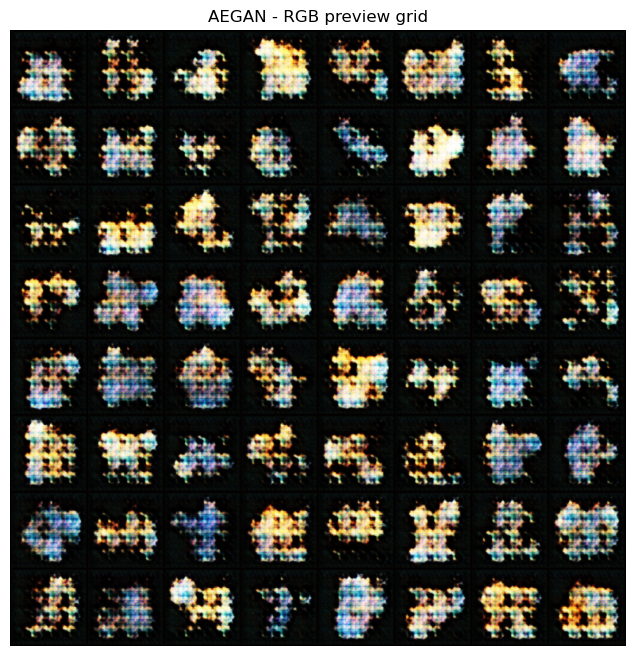

In [12]:
@torch.no_grad()
def show_generated_grid(n=64, nrow=8):
    z = torch.randn(n, latent_dim, device=device)
    fake = G(z).detach().cpu()
    fake_vis = ((fake + 1) / 2).clamp(0, 1)

    grid = torchvision.utils.make_grid(fake_vis[:, :3], nrow=nrow)
    plt.figure(figsize=(8, 8))
    plt.imshow(grid.permute(1, 2, 0))
    plt.title("AEGAN - RGB preview grid")
    plt.axis("off")

show_generated_grid()

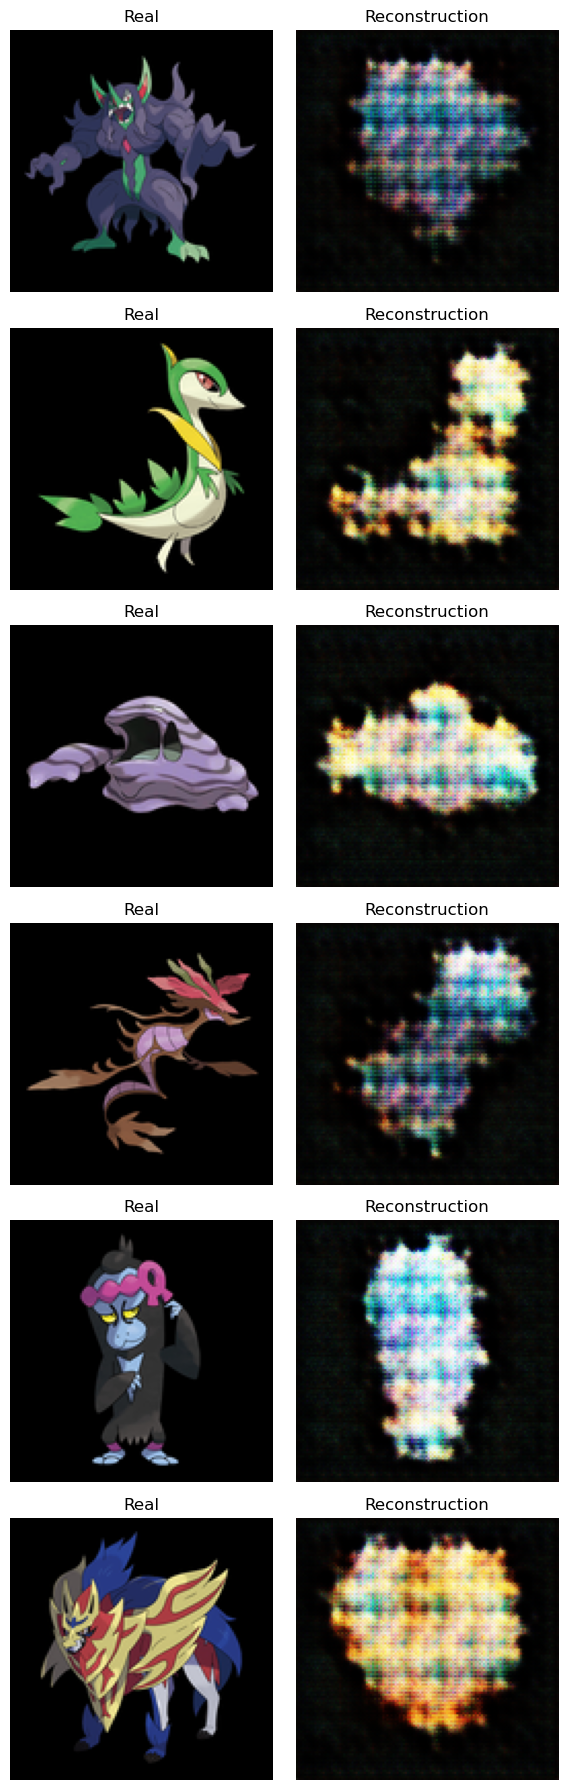

In [13]:
@torch.no_grad()
def show_reconstructions(num_samples=6):
    real, _ = next(iter(loader))
    real = real[:num_samples].to(device)
    recon = G(E(real)).cpu()
    real = real.cpu()

    real_vis = ((real + 1) / 2).clamp(0, 1)
    recon_vis = ((recon + 1) / 2).clamp(0, 1)

    fig, axes = plt.subplots(num_samples, 2, figsize=(6, 3 * num_samples))
    for i in range(num_samples):
        axes[i, 0].imshow(real_vis[i, :3].permute(1, 2, 0))
        axes[i, 0].set_title("Real")
        axes[i, 0].axis("off")

        axes[i, 1].imshow(recon_vis[i, :3].permute(1, 2, 0))
        axes[i, 1].set_title("Reconstruction")
        axes[i, 1].axis("off")

    plt.tight_layout()

show_reconstructions()

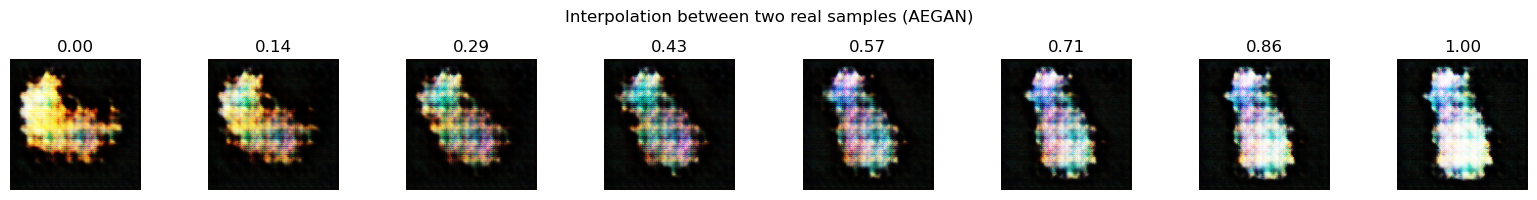

In [14]:
@torch.no_grad()
def interpolate_real_samples(steps=8):
    real, _ = next(iter(loader))
    x1 = real[0:1].to(device)
    x2 = real[1:2].to(device)

    z1 = E(x1)
    z2 = E(x2)

    alphas = torch.linspace(0, 1, steps, device=device)
    z_interp = torch.stack([(1 - a) * z1[0] + a * z2[0] for a in alphas], dim=0)
    x_interp = G(z_interp).cpu()
    x_interp = ((x_interp + 1) / 2).clamp(0, 1)

    fig, axes = plt.subplots(1, steps, figsize=(2 * steps, 2))
    for i in range(steps):
        axes[i].imshow(x_interp[i, :3].permute(1, 2, 0))
        axes[i].axis("off")
        axes[i].set_title(f"{i/(steps-1):.2f}")
    plt.suptitle("Interpolation between two real samples (AEGAN)")
    plt.tight_layout()

interpolate_real_samples()

In [15]:
save_dir = "checkpoints_aegan"
os.makedirs(save_dir, exist_ok=True)

torch.save({
    "encoder": E.state_dict(),
    "generator": G.state_dict(),
    "dx": Dx.state_dict(),
    "dz": Dz.state_dict(),
    "config": {
        "image_size": image_size,
        "latent_dim": latent_dim,
        "lambda_rx": lambda_rx,
        "lambda_rz": lambda_rz,
    }
}, os.path.join(save_dir, f"aegan_{image_size}.pt"))

print("Checkpoint saved.")

Checkpoint saved.
